In [1]:
import numpy as np
import networkx as nx
from scipy.ndimage import binary_dilation
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
from shapely import Polygon
from skimage import measure
import networkx as nx
import skimage as ski
import dask.array as da
from shapely.strtree import STRtree
from scipy.spatial import ConvexHull, Delaunay, delaunay_plot_2d, convex_hull_plot_2d
import scipy.ndimage as ndi
import ast
from extract_features import subimage
from collections import defaultdict
from misc_utils import fixup_scipy_ndimage_result as fix
from misc_utils import strel_disk
import plotly.express as px
import dask_image.ndmeasure
import scipy.signal
import time
from itertools import zip_longest
from dask.distributed import Client
import dask.delayed

In [2]:
# @dask.delayed
def neighbors_for_object(object_number, min_i, max_i, min_j, max_j, img_path, strel, distance):
    img = tifffile.memmap(img_path)
    patch = img[
        min_i : max_i,
        min_j : max_j,
    ]

    #
    # Find the neighbors
    #
    
    patch_mask = patch == (object_number)

    if distance <= 5:
        extended = ndi.binary_dilation(patch_mask, strel)
    else:
        extended = (
            scipy.signal.fftconvolve(patch_mask, strel, mode="same") > 0.5
        )

    neighbors = np.unique(patch[extended])

    neighbors = neighbors[(neighbors != 0) & (neighbors != object_number)]

    if hasattr(neighbors, "compute"):
        neighbors = neighbors.compute()

    return [(int(n), int(object_number)) for n in neighbors]


In [3]:
img_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_o8p_day24_s12_cyto_mask.tif"
# y0 = 4000
# x0 = 10000
# slice = [4000:4000+4000, 10000:10000+8400]
labels = tifffile.memmap(img_path)

In [4]:
nobjects = np.max(labels)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
distance = 25
strel = strel_disk(distance)

objs = ndi.find_objects(labels, max_label=nobjects)
# objs is a list of slice-tuples, one per label 1..nobjects
# missing labels give None

minimums_i = np.empty(nobjects, dtype=np.int64)
maximums_i = np.empty(nobjects, dtype=np.int64)
minimums_j = np.empty(nobjects, dtype=np.int64)
maximums_j = np.empty(nobjects, dtype=np.int64)

for k, slc in enumerate(objs):
    if slc is None:
        minimums_i[k] = 0
        maximums_i[k] = 0
        minimums_j[k] = 0
        maximums_j[k] = 0
        continue

    si, sj = slc
    minimums_i[k] = max(si.start - distance, 0)
    maximums_i[k] = min(si.stop  + distance, labels.shape[0])
    minimums_j[k] = max(sj.start - distance, 0)
    maximums_j[k] = min(sj.stop  + distance, labels.shape[1])

In [5]:
client = Client()

futures = client.map(
    neighbors_for_object,
    object_indexes.tolist(),
    minimums_i.tolist(),
    maximums_i.tolist(),
    minimums_j.tolist(),
    maximums_j.tolist(),
    [img_path] * len(object_indexes),
    [strel] * len(object_indexes),
    [distance] * len(object_indexes),
)

result = client.gather(futures)
edges = [edge for sublist in result for edge in sublist]

In [7]:
int(object_indexes)

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [11]:
object_indexes = np.arange(nobjects, dtype=int) + 1

In [14]:
str(object_indexes[0])

'1'

In [15]:
G = nx.Graph()
G.add_nodes_from(object_indexes)
G.add_edges_from(edges)
components = list(nx.connected_components(G))
nx.write_gml(G, "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_o8p_day24_s12.gml", stringizer=str)

In [ ]:
# labels,_,_ = ski.segmentation.relabel_sequential(labels, offset=1)
# labels = da.from_array(labels)
nobjects = np.max(labels)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
distance = 25
strel = strel_disk(distance)

In [ ]:
def prepare_box_for_contours(box, shape, pad=3):
    """Marginally pads a bounding box so that object boundaries
    are not on cropped image patch edges.
    """
    for i in range(2):
        box[i] = max(0, box[i] - pad)
        box[i+2] = min(shape[i], box[i+2] + pad)
    slices = tuple([slice(box[i], box[i+2]) for i in range(2)])
    top_left = np.array(box[:2])[None] # (1, 2)
    return slices, top_left

def make_polygons_from_mask(mask):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    polygons = {}
    for rp in measure.regionprops(mask):
        # Faster to compute contours on small cell tiles than the whole image
        box_slices, box_top_left = prepare_box_for_contours(list(rp.bbox), mask.shape)
        label_mask = mask[box_slices] == rp.label

        label_cnts = np.concatenate(
            measure.find_contours(label_mask), axis=0
        )

        polygons[rp.label] = Polygon(label_cnts + box_top_left)
    
    return polygons

def make_polygons_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    polygons = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        polygons[lab] = Polygon(label_cnts + box_top_left)
    
    return polygons

def make_hull_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    hulls = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        hulls[lab] = ConvexHull(label_cnts + box_top_left)
    
    return hulls

def make_delaunay_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    tris = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        tris[lab] = Delaunay(label_cnts + box_top_left)
    
    return tris

def pairwise_polygon_distance(polygons_dict, dist):
    """Computes pairwise distance between all polygons in
    a dictionary. Returns a dictionary of distances.
    """
    polys = list(polygons_dict.values())
    ids = list(polygons_dict.keys())

    tree = STRtree(polys)

    id_map = dict(zip(polys, ids))

    distances = {i: {} for i in ids}

    for poly in polys:
        i = id_map[poly]

        # query nearby polygons using bounding boxes
        candidates = tree.query(poly.buffer(dist))  # 5 px search radius

        for other in candidates:
            j = id_map[other]
            if i == j:
                continue

            d = poly.distance(other)
            distances[i][j] = d
                
    return distances

def get_contour_from_label(mask, labels, df = cell_coords, scaled=True):
    contours = defaultdict(int)
    if not isinstance(labels, list):
        labels = list(labels)
    
    for label in labels:
        box = subimage(mask, df.at[label, "cells_bounds"], pad=5)

        label_cnts = np.concatenate(
        measure.find_contours(box), axis=0
            )
        
        if scaled:
            box_top_left = np.array(df.at[label, "cells_bounds"][:2])[None]
            contours[label] = label_cnts + box_top_left
        else:
            contours[label] = label_cnts
            
    return contours

In [ ]:
# i, j = np.mgrid[0 : labels.shape[0], 0 : labels.shape[1]]
i, j = da.meshgrid(da.arange(labels.shape[0]),da.arange(labels.shape[1]))
i = i.T
j = j.T

minimums_i, maximums_i, _, _ = dask_image.ndmeasure.extrema(
    i, labels, object_indexes
)
minimums_j, maximums_j, _, _ = dask_image.ndmeasure.extrema(
    j, labels, object_indexes
)

minimums_i = da.maximum(fix(minimums_i) - distance, 0).astype(int)
maximums_i = da.minimum(
    fix(maximums_i) + distance + 1, labels.shape[0]
).astype(int)
minimums_j = da.maximum(fix(minimums_j) - distance, 0).astype(int)
maximums_j = da.minimum(
    fix(maximums_j) + distance + 1, labels.shape[1]
).astype(int)

minimums_i, maximums_i, minimums_j, maximums_j = da.compute(
    minimums_i, maximums_i, minimums_j, maximums_j
)

del i, j

In [ ]:
objs = ndi.find_objects(labels, max_label=nobjects)
# objs is a list of slice-tuples, one per label 1..nobjects
# missing labels give None

minimums_i = np.empty(nobjects, dtype=np.int64)
maximums_i = np.empty(nobjects, dtype=np.int64)
minimums_j = np.empty(nobjects, dtype=np.int64)
maximums_j = np.empty(nobjects, dtype=np.int64)

for k, slc in enumerate(objs):
    if slc is None:
        minimums_i[k] = 0
        maximums_i[k] = 0
        minimums_j[k] = 0
        maximums_j[k] = 0
        continue

    si, sj = slc
    minimums_i[k] = max(si.start - distance, 0)
    maximums_i[k] = min(si.stop  + distance, labels.shape[0])
    minimums_j[k] = max(sj.start - distance, 0)
    maximums_j[k] = min(sj.stop  + distance, labels.shape[1])

In [ ]:
edges = list()

tPatch = 0
tMask = 0
tExtend = 0
tEdges = 0

def neighbors_for_object(img, object_number, min_i, max_i, min_j, max_j, strel, distance):
    t0 = time.time()

    index = object_number - 1

    patch = img[
        min_i : max_i,
        min_j : max_j,
    ]
    tPatch += (time.time() - t0)
    t0 = time.time()
    #
    # Find the neighbors
    #
    
    patch_mask = patch == (index + 1)
    tMask += (time.time() - t0)
    t0 = time.time()

    if distance <= 5:
        extended = ndi.binary_dilation(patch_mask, strel)
    else:
        extended = (
            scipy.signal.fftconvolve(patch_mask, strel, mode="same") > 0.5
        )
    tExtend += (time.time() - t0)
    t0 = time.time()

    neighbors = np.unique(patch[extended])
    neighbors = neighbors[neighbors != 0]
    neighbors = neighbors[neighbors != object_number]
    if hasattr(neighbors,"compute"):
        neighbors = neighbors.compute()
    edges.extend([(int(n), int(object_number)) for n in neighbors])
    tEdges += (time.time() - t0)

print(f"Make patch: {tPatch} s \nMask patch: {tMask} s\n \
      Dilation/fftconvolve: {tExtend} s\n Add edges: {tEdges} s"
      )

In [ ]:
t1 = time.time()
edges1 = list()
object_number = 65
neighbors = np.arange(50)
for n in neighbors:
    edges1.append(tuple(sorted((n,object_number))))
t2 = time.time()
obj_fill = np.full_like(neighbors, object_number)
edges2 = zip(neighbors,obj_fill)
t3 = time.time()
edges3 = zip_longest(neighbors,fillvalue=object_number)
t4 = time.time()
print(t2-t1)
print(t3-t2)
print(t4-t3)

In [ ]:
y = list()

h = np.unique([7,7,0,0,0])
b = np.unique([7,7,0,0,0,4,3,1,9])


h = h[h!=0]
h = h[h!=7]
b = b[b!=0]
b = b[b!=7]

y.extend(zip_longest(h,[],fillvalue=12))
y.extend(zip_longest(b,[],fillvalue=12))
y

In [16]:
colony_map = {}
for k, comp in enumerate(components, start=1):
    if len(comp) < 3:
        for cell_id in comp:
            colony_map[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map[cell_id] = k

In [20]:
df = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/o8p_day24_s12_results.csv", index_col="label",converters={"cells_bounds":ast.literal_eval}).drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"])
# df = df[df.index.isin(np.unique(mask_region))]

df["colony_id"] = df.index.map(colony_map)

In [ ]:
pd.con

,nucleus_area,nucleus_i,nucleus_j,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,cells_area,cells_i,...,cells_eccentricity,foci_count,foci_area,nucleus_number_neighbors_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,cells_number_neighbors_1,cells_percent_touching_1,cells_first_neighbor_distance,cells_second_neighbor_distance
label,,,,,,,,,,,,,,,,,,,,,
1,1069,1626.681946,25270.460243,1917.960711,2737,1033,332.572849,0.711610,6102,1647.967552,...,0.846173,10,117,0,1838.055437,1991.112228,0,NaN,1831.494500,1974.304726
2,1091,1836.065078,22567.976169,1080.065078,1759,379,249.204348,0.459015,5327,1819.838183,...,0.908882,1,2,0,1377.943193,1387.774393,0,NaN,1388.385072,1400.316236
3,1279,2330.057076,15284.928851,2057.698984,3273,332,372.990217,0.664652,5996,2319.671948,...,0.945546,12,226,0,646.323985,1868.422464,0,NaN,668.660212,1878.341570
4,2064,2759.281008,23822.818314,1078.665698,2011,279,294.094888,0.654092,6918,2771.641081,...,0.932986,2,18,0,164.794390,247.537171,0,NaN,86.141115,217.963506
5,1940,2788.794845,23577.046907,970.484536,1859,190,277.138514,0.655708,6460,2758.164241,...,0.407405,12,231,0,87.994696,247.537171,0,NaN,149.044007,217.963506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4508,7540,39124.704775,18869.474668,197.401724,766,0,170.649570,0.830990,3170,39002.306309,...,0.436902,38,1758,0,131.103677,167.273222,1,NaN,61.596760,129.831054
4509,3516,39305.602673,20307.226394,107.144767,296,0,58.527663,0.780247,10376,39126.217714,...,0.883823,7,233,0,441.903642,493.008795,0,NaN,129.831054,174.654208
4510,4690,39664.264819,23492.662473,1568.605970,3280,107,869.739035,0.611145,13679,39335.801082,...,0.961377,19,498,0,3205.564155,3424.096047,0,NaN,473.571636,479.831698


In [ ]:
max_label = labels.max()

label_to_colony = np.full(max_label + 1, 0, dtype=int)
for cell_id, colony_id in colony_map.items():
    label_to_colony[cell_id] = colony_id
    
colony_img = label_to_colony[labels]

ids = np.unique(colony_img)
ids = ids[ids>0]
cmap = plt.get_cmap("tab20", len(ids))

label_to_color = {
    lab: cmap(i)
    for i, lab in enumerate(ids)
}

# set background / non-colony
label_to_color[-1] = (0.7, 0.7, 0.7, 1)
label_to_color[0] = (0,0,0, 1)

colors_array = np.zeros((max_label + 1, 4))

for lab, color in label_to_color.items():
    colors_array[lab] = color

rgb = colors_array[colony_img]


plt.imshow(rgb)

In [ ]:
px.imshow(labels)

In [ ]:
threshold = 10
both_borders = ski.segmentation.find_boundaries(both, mode="inner")*both
dilated = ndi.grey_dilation(both_borders, size=(2*threshold+1, 2*threshold+1))
plt.imshow(dilated)

In [ ]:
threshold = 10
borders_region = ski.segmentation.find_boundaries(mask_region.compute())*mask_region
dilated_region = ndi.grey_dilation(borders_region, size=(2*threshold+1, 2*threshold+1))
plt.imshow(dilated_region)

In [ ]:
edges = set()

# horizontal neighbors
a = dilated_region[:, :-1]
b = dilated_region[:, 1:]

mask_diff = (a != b) & (a > 0) & (b > 0)

pairs = np.stack([a[mask_diff], b[mask_diff]], axis=1)

for i, j in pairs:
    if i != j:
        edges.add(tuple(sorted((i, j))))

a = dilated_region[:-1, :]
b = dilated_region[1:, :]

mask_diff = (a != b) & (a > 0) & (b > 0)

pairs = np.stack([a[mask_diff], b[mask_diff]], axis=1)

for i, j in pairs:
    if i != j:
        edges.add(tuple(sorted((i, j))))

G = nx.Graph()
G.add_nodes_from(np.unique(mask_region.compute())[1:])
G.add_edges_from(edges)
components = list(nx.connected_components(G))

colony_map = {}
for k, comp in enumerate(components, start=1):
    if len(comp) < 3:
        for cell_id in comp:
            colony_map[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map[cell_id] = k

cell_coords["colony_id"] = cell_coords.index.map(colony_map)


In [ ]:
max_label = dilated_region.max()

label_to_colony = np.full(max_label + 1, 0, dtype=int)
for cell_id, colony_id in colony_map.items():
    label_to_colony[cell_id] = colony_id
    
colony_img = label_to_colony[dilated_region]

ids = np.unique(colony_img)
ids = ids[ids>0]
cmap = plt.get_cmap("tab20", len(ids))

label_to_color = {
    lab: cmap(i)
    for i, lab in enumerate(ids)
}

# set background / non-colony
label_to_color[-1] = (0.7, 0.7, 0.7, 1)
label_to_color[0] = (0,0,0, 1)

colors_array = np.zeros((max_label + 1, 4))

for lab, color in label_to_color.items():
    colors_array[lab] = color

rgb = colors_array[colony_img]


plt.imshow(rgb)

In [ ]:
colony_map = {}
for k, comp in enumerate(components, start=1):
    if len(comp) < 3:
        for cell_id in comp:
            colony_map[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map[cell_id] = k

cell_coords["colony_id"] = cell_coords.index.map(colony_map)

# sizes = df["colony_id_poly"].value_counts()

# valid = sizes[sizes >= 10].index

# df["in_colony"] = df["colony_id_poly"].isin(valid)

In [ ]:
distances = pd.DataFrame(distances_dict)
distances_flat = distances.to_numpy().flatten()
distances_flat = distances_flat[~np.isnan(distances_flat)]

In [ ]:
G = nx.Graph()

# add all cells
G.add_nodes_from(polygons_dict.keys())

threshold = 20  # adjust

for i, neighbors in distances_dict.items():
    for j, d in neighbors.items():
        if d <= threshold:
            G.add_edge(i, j)

components = list(nx.connected_components(G))

colony_map = {}
for k, comp in enumerate(components):
    for cell_id in comp:
        colony_map[cell_id] = k

df["colony_id_poly"] = df.index.map(colony_map)

sizes = df["colony_id_poly"].value_counts()

valid = sizes[sizes >= 10].index

df["in_colony"] = df["colony_id_poly"].isin(valid)

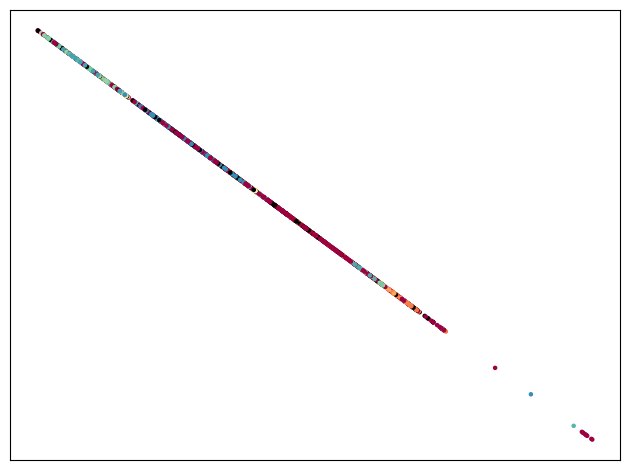

In [24]:
sizes = df["colony_id"].value_counts()

valid = sizes[sizes >= 10].index

df["in_colony"] = df["colony_id"].isin(valid)

labels = df["colony_id"].values
unique_labels = np.unique(labels)

# assign a color to each label
colors_map = {
    lab: plt.cm.Spectral(i / len(unique_labels))
    for i, lab in enumerate(unique_labels)
}

# override noise (-1) to black
filtered_dict = {key:(value if np.isin(key,valid)
          else (0, 0, 0, 1)) for key, value in colors_map.items()}

# build color list per point
colors = [filtered_dict[lab] for lab in labels]

fig, ax = plt.subplots()

ax.scatter(
    df["nucleus_j"],
    df["nucleus_j"],
    c=colors,
    s=5
)

ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()

# ax[1].imshow(ski.exposure.rescale_intensity(img[1], in_range=(0,3000)))
# ax[1].set_xticks([])
# ax[1].set_yticks([])
plt.tight_layout()
plt.show()

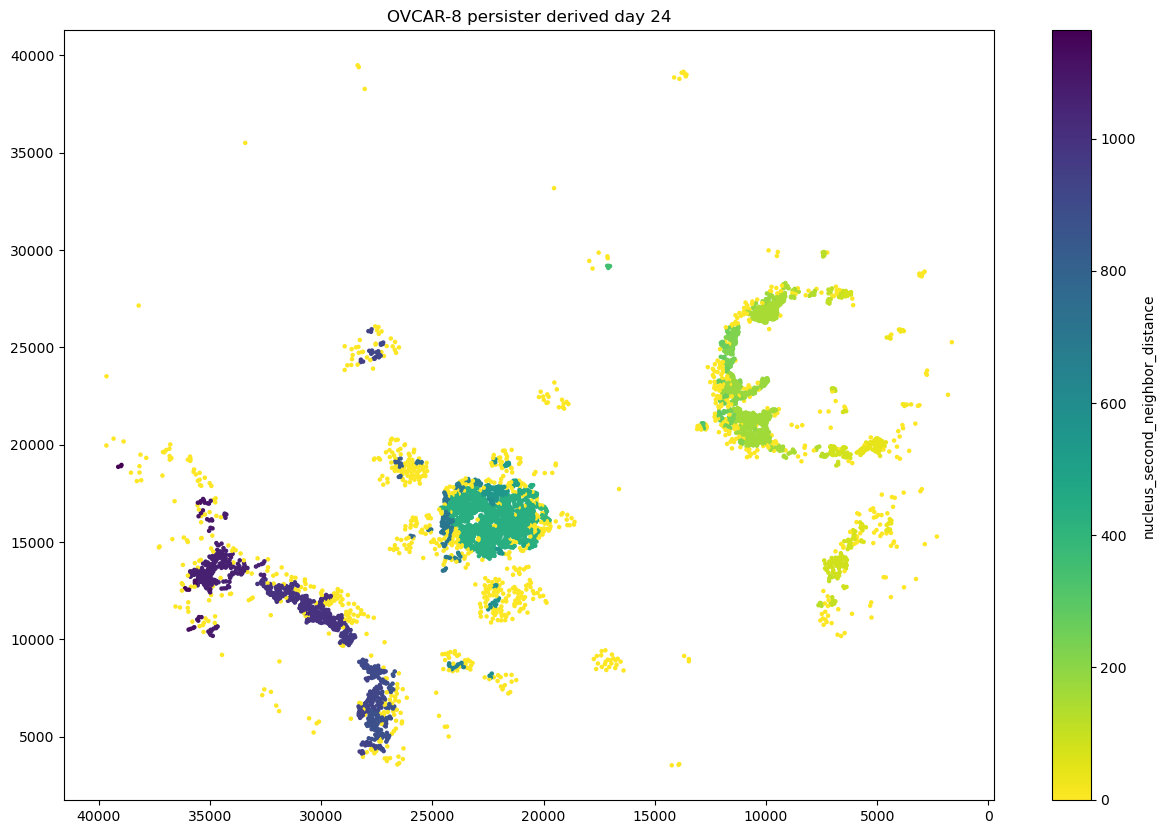

In [30]:
plt.figure(figsize=(15,10))

plt.scatter(
    df["cells_i"],
    df["cells_j"],
    c=df["colony_id"],
    s=5,
    cmap="viridis_r"
)

plt.colorbar(label="nucleus_second_neighbor_distance")
plt.title("OVCAR-8 persister derived day 24")
plt.gca().invert_xaxis()
plt.show()

In [29]:
df

,nucleus_area,nucleus_i,nucleus_j,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,cells_area,cells_i,...,foci_area,nucleus_number_neighbors_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,cells_number_neighbors_1,cells_percent_touching_1,cells_first_neighbor_distance,cells_second_neighbor_distance,colony_id,in_colony
label,,,,,,,,,,,,,,,,,,,,,
1,1069,1626.681946,25270.460243,1917.960711,2737,1033,332.572849,0.711610,6102,1647.967552,...,117,0,1838.055437,1991.112228,0,NaN,1831.494500,1974.304726,-1,True
2,1091,1836.065078,22567.976169,1080.065078,1759,379,249.204348,0.459015,5327,1819.838183,...,2,0,1377.943193,1387.774393,0,NaN,1388.385072,1400.316236,-1,True
3,1279,2330.057076,15284.928851,2057.698984,3273,332,372.990217,0.664652,5996,2319.671948,...,226,0,646.323985,1868.422464,0,NaN,668.660212,1878.341570,-1,True
4,2064,2759.281008,23822.818314,1078.665698,2011,279,294.094888,0.654092,6918,2771.641081,...,18,0,164.794390,247.537171,0,NaN,86.141115,217.963506,-1,True
5,1940,2788.794845,23577.046907,970.484536,1859,190,277.138514,0.655708,6460,2758.164241,...,231,0,87.994696,247.537171,0,NaN,149.044007,217.963506,-1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4508,7540,39124.704775,18869.474668,197.401724,766,0,170.649570,0.830990,3170,39002.306309,...,1758,0,131.103677,167.273222,1,NaN,61.596760,129.831054,1164,False
4509,3516,39305.602673,20307.226394,107.144767,296,0,58.527663,0.780247,10376,39126.217714,...,233,0,441.903642,493.008795,0,NaN,129.831054,174.654208,1164,False
4510,4690,39664.264819,23492.662473,1568.605970,3280,107,869.739035,0.611145,13679,39335.801082,...,498,0,3205.564155,3424.096047,0,NaN,473.571636,479.831698,-1,True


In [ ]:
fig, ax = plt.subplots(ncols=2,figsize=(20,10))

for i in range(2):
    ax[i].imshow(ski.exposure.rescale_intensity(img[i], in_range=(0,3000)))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()